In [22]:
import numpy as np
import matplotlib.pyplot as plt
x, w = np.polynomial.laguerre.laggauss(50)
xj, wj = np.polynomial.legendre.leggauss(50)
import ODESolve_slow as ODE
import derivatives as der
from constants import GF, gA, me, hbar, dmnp, mpl
import weakrates as weak
import expansion as ex

In [24]:
#solve ODE
a0=0.1    
y0=np.array([10,0,(1+(weak.Npntot(10,a0))/(weak.Nnptot(10,a0)) )**(-1),1-(1+(weak.Npntot(10,a0))/(weak.Nnptot(10,a0)) )**(-1)])
dx0=0.001
p=None

N_step = 1000
dN = 2
x_final = 100
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


Text(0, 0.5, 'rate (s^-1)')

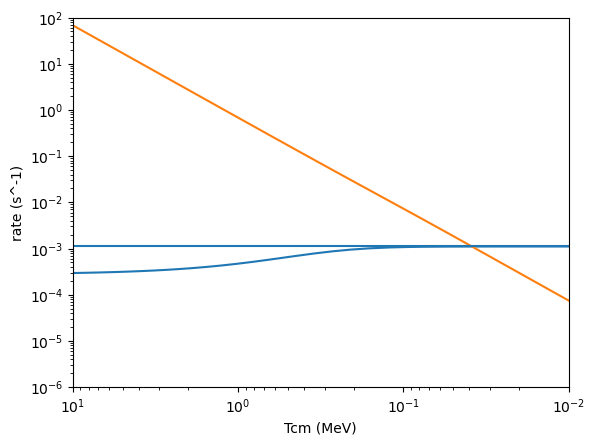

In [25]:
#Figure 2

plt.figure()
T = y[:,0]
z = np.zeros(len(T))
N7 = np.zeros(len(T))
for i in range(len(T)):
    z[i] = weak.N(T[i],a[i])/hbar
    N7[i] = ex.H(T[i],a[i])/hbar
plt.loglog(1/a,z)
plt.loglog(1/a,N7)
plt.xlim(1e1,1e-2)
plt.ylim(1e-6,1e2)
plt.axhline(1/903)
plt.xlabel("Tcm (MeV)")
plt.ylabel("rate (s^-1)")


Text(0, 0.5, 'rate (s^-1)')

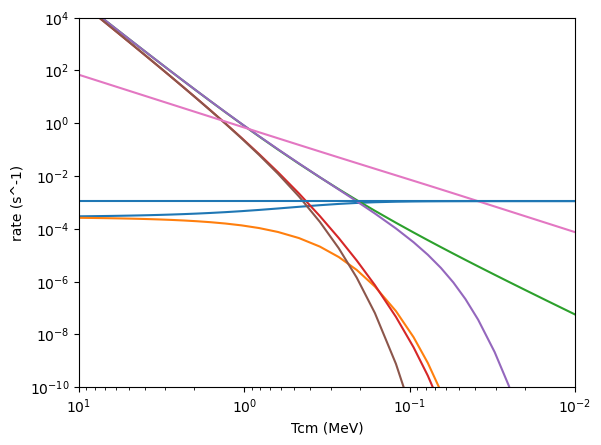

In [26]:
#Figure 1

plt.figure()
T = y[:,0]
N1 = np.zeros(len(1/a))
N2 = np.zeros(len(1/a))
N3 = np.zeros(len(1/a))
N4 = np.zeros(len(1/a))
N5 = np.zeros(len(1/a))
N6 = np.zeros(len(1/a))
N7 = np.zeros(len(1/a))

for i in range(len(T)):
    N1[i] = weak.N(T[i],a[i])/hbar
    N2[i] = weak.N_antiep(T[i],a[i])/hbar
    N3[i] = weak.N_neutrinoen(T[i],a[i])/hbar
    N4[i] = weak.N_ep(T[i],a[i])/hbar
    N5[i] = weak.N_posn(T[i],a[i])/hbar
    N6[i] = weak.N_antip(T[i],a[i])/hbar
    N7[i] = ex.H(T[i],a[i])/hbar
plt.loglog(1/a,N1)
plt.loglog(1/a,N2)
plt.loglog(1/a,N3)
plt.loglog(1/a,N4)
plt.loglog(1/a,N5)
plt.loglog(1/a,N6)
plt.loglog(1/a,N7)
plt.xlim(1e1,1e-2)
plt.ylim(1e-10,1e4)
plt.axhline(1/903)
plt.xlabel("Tcm (MeV)")
plt.ylabel("rate (s^-1)")


In [27]:
def Nnptot(T,a):
    Nnptot = weak.N_posn(T,a) + weak.N_neutrinoen(T,a) + weak.N(T,a)
    return Nnptot
    

In [29]:
def Npntot(T,a):
    Npntot = weak.N_antiep(T,a) + weak.N_ep(T,a) + weak.N_antip(T,a)
    return Npntot
    

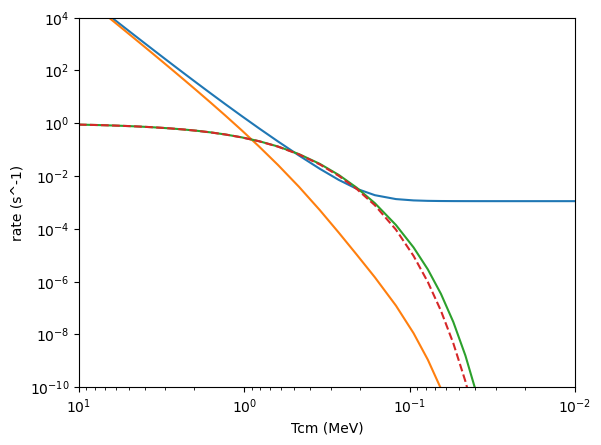

In [31]:
plt.figure()
T = y[:,0]
Tcm=1/a

z1 = np.zeros(len(T))
z2 = np.zeros(len(T))

for i in range(len(T)):
    z1[i]= Nnptot(T[i],a[i])/hbar
    z2[i]= Npntot(T[i],a[i])/hbar

plt.loglog(Tcm,z1)
plt.loglog(Tcm,z2)
plt.xlim(1e1,1e-2)
plt.ylim(1e-10,1e4)
plt.xlabel("Tcm (MeV)")
plt.ylabel("rate (s^-1)")
plt.loglog(Tcm, np.exp(-dmnp/T))
plt.loglog(Tcm,z2/z1, linestyle='--')

In [35]:
#solve ODE
a0 = 0.1    
y0 = np.array([10,0,0,0])
y0[2] = (1+(weak.Npntot(y0[0],a0))/(weak.Nnptot(y0[0],a0)) )**(-1)
y0[3] = 1- y0[2]

dx0=0.001
p=None

N_step = 1000

dN = 10
x_final = 100
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


RuntimeError: You must first define an image, e.g., with imshow

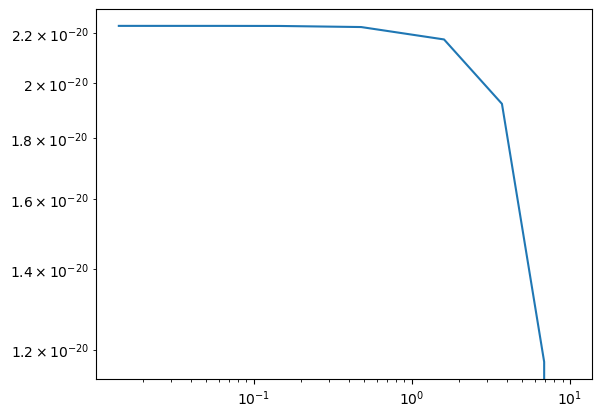

In [72]:
plt.figure()
t=y[:,1]
T=y[:,0]
plt.loglog(T,t)
plt.clim(1.5,0.01)